# Warehouse Inventory Analysis Project

## Project Introduction
This project analyzes warehouse inventory data to understand demand patterns, supplier performance, inventory efficiency, stock availability, inventory cost, product quality, and warehouse demand pressure.

## Problem Statement
Warehouse managers need to maintain sufficient stock to satisfy demand while avoiding stockouts, backorders, excess inventory, and unnecessary holding costs. Demand variability, supplier lead times, supplier delays, reorder-point breaches, and product quality issues can affect operational performance.

The objective is to identify important product-, category-, and warehouse-level patterns and relationships that can support better inventory decisions.

## Project Deliverables
1. Data acquisition and understanding
2. Basic data inspection and cleaning checks
3. Missing-value and duplicate analysis
4. Exploratory data analysis and visualizations
5. Analysis of all requested business questions
6. Cell-by-cell interpretation
7. Final business insights and conclusion

## Data Description
The dataset contains product-level information about categories, suppliers, warehouse zones, demand, demand variability, supplier lead time, reorder activity, stock turnover, inventory duration, stockouts, backorders, safety stock, excess stock, inventory value, costs, returns, damages, and warehouse demand pressure.

## Data Acquisition
The dataset used is the provided file `warehouse_inventory_clustering_dataset(4).csv`.

## 1. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/suchismitarout/Downloads/warehouse_inventory_clustering_dataset.csv")
df.shape

(4000, 25)

### Interpretation
The dataset was successfully loaded and contains **4,000 rows and 25 columns**.

## 2. First Five Rows

In [2]:
df.head()

,item_id,category,subcategory,supplier_id,warehouse_zone,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,...,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
0,ITM00001,Grocery,Snacks,S1036,B2,310,0.26,7.8,0.05,8,...,0.012,10.83,132.98,1,2,249,75,46,33112.02,161.12
1,ITM00002,Industrial,Electrical Parts,S1036,B1,455,0.16,4.8,0.08,8,...,0.007,45.57,1525.56,0,0,362,94,34,552252.72,141.27
2,ITM00003,Apparel,Jackets,S1011,B2,350,0.43,20.9,0.57,6,...,0.010,18.47,457.56,3,9,317,105,146,145046.52,238.29
3,ITM00004,Automotive,Lubricants,S1030,A1,121,0.33,4.6,0.12,1,...,0.017,168.71,1779.38,0,1,183,32,84,325626.54,87.90
4,ITM00005,Pharmaceutical,Medical Devices,S1064,A2,85,0.14,7.3,0.15,1,...,0.016,33.33,731.83,2,4,209,17,180,152952.47,86.85


### Interpretation
The first five rows provide an initial view of the product-level records and the variables available for analysis.

## 3. Last Five Rows

In [3]:
df.tail()

,item_id,category,subcategory,supplier_id,warehouse_zone,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,...,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
3995,ITM03996,Pharmaceutical,OTC Medicine,S1003,C2,61,0.33,7.3,0.35,3,...,0.019,12.12,404.91,0,0,274,16,248,110945.34,28.77
3996,ITM03997,Automotive,Batteries,S1007,C1,487,0.40,13.8,0.50,6,...,0.026,45.95,844.98,10,5,371,141,18,313487.58,245.03
3997,ITM03998,Industrial,Fasteners,S1064,D2,32,0.61,10.9,0.36,2,...,0.020,60.67,1743.43,2,2,200,12,174,348686.00,56.08
3998,ITM03999,Stationery,Writing Tools,S1056,D1,571,0.42,11.8,0.41,11,...,0.015,4.62,132.21,5,12,511,170,52,67559.31,200.31
3999,ITM04000,Pharmaceutical,OTC Medicine,S1022,A1,540,0.13,6.4,0.08,7,...,0.018,11.49,218.83,2,1,453,106,8,99129.99,130.47


### Interpretation
The last five rows confirm that the dataset has been loaded completely and follows the same structure throughout.

## 4. Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   item_id                          4000 non-null   object 
 1   category                         4000 non-null   object 
 2   subcategory                      4000 non-null   object 
 3   supplier_id                      4000 non-null   object 
 4   warehouse_zone                   4000 non-null   object 
 5   avg_monthly_demand               4000 non-null   int64  
 6   demand_variability               4000 non-null   float64
 7   avg_lead_time_days               4000 non-null   float64
 8   lead_time_variability            4000 non-null   float64
 9   monthly_reorder_count            4000 non-null   int64  
 10  stock_turnover_ratio             4000 non-null   float64
 11  days_in_inventory                4000 non-null   int64  
 12  stockout_frequency  

### Interpretation
The information output shows the data types and non-null counts. All columns contain 4,000 observations, so there are no missing records.

## 5. Column Names

In [5]:
df.columns.tolist()

['item_id',
 'category',
 'subcategory',
 'supplier_id',
 'warehouse_zone',
 'avg_monthly_demand',
 'demand_variability',
 'avg_lead_time_days',
 'lead_time_variability',
 'monthly_reorder_count',
 'stock_turnover_ratio',
 'days_in_inventory',
 'stockout_frequency',
 'backorder_frequency',
 'return_rate',
 'damage_rate',
 'holding_cost_per_unit',
 'unit_cost',
 'reorder_point_breaches',
 'supplier_delay_incidents',
 'current_stock',
 'safety_stock',
 'excess_stock_level',
 'inventory_value',
 'warehouse_demand_pressure_index']

### Interpretation
The columns cover product, category, supplier, warehouse, demand, inventory, cost, quality, and operational-performance information.

## 6. Data Types

In [6]:
df.dtypes

item_id                             object
category                            object
subcategory                         object
supplier_id                         object
warehouse_zone                      object
avg_monthly_demand                   int64
demand_variability                 float64
avg_lead_time_days                 float64
lead_time_variability              float64
monthly_reorder_count                int64
stock_turnover_ratio               float64
days_in_inventory                    int64
stockout_frequency                   int64
backorder_frequency                  int64
return_rate                        float64
damage_rate                        float64
holding_cost_per_unit              float64
unit_cost                          float64
reorder_point_breaches               int64
supplier_delay_incidents             int64
current_stock                        int64
safety_stock                         int64
excess_stock_level                   int64
inventory_v

### Interpretation
The dataset contains both categorical and numerical variables. Categorical variables support grouping, while numerical variables support statistical and graphical analysis.

## 7. Descriptive Statistics

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
avg_monthly_demand,4000.0,331.809250,228.438284,1.000,103.0000,333.000,523.2500,983.00
demand_variability,4000.0,0.285640,0.128173,0.080,0.1900,0.260,0.3700,0.62
avg_lead_time_days,4000.0,10.301275,5.592473,1.000,6.2000,9.000,13.4000,35.00
lead_time_variability,4000.0,0.258738,0.165963,0.050,0.1300,0.200,0.3600,0.72
monthly_reorder_count,4000.0,4.707250,2.991118,0.000,2.0000,5.000,7.0000,14.00
stock_turnover_ratio,4000.0,5.944282,3.804082,0.200,2.1400,6.150,9.1400,15.89
days_in_inventory,4000.0,65.489750,56.855528,4.000,22.0000,34.000,106.0000,273.00
stockout_frequency,4000.0,2.491250,3.192487,0.000,0.0000,1.000,4.0000,15.00
backorder_frequency,4000.0,1.938000,2.503642,0.000,0.0000,1.000,3.0000,14.00
return_rate,4000.0,0.028485,0.015560,0.005,0.0170,0.026,0.0370,0.08


### Interpretation
The descriptive statistics show variation in demand, lead time, turnover, stock availability, costs, and other inventory measures. This supports deeper product- and group-level analysis.

## 8. Missing Values

In [8]:
df.isnull().sum()

item_id                            0
category                           0
subcategory                        0
supplier_id                        0
warehouse_zone                     0
avg_monthly_demand                 0
demand_variability                 0
avg_lead_time_days                 0
lead_time_variability              0
monthly_reorder_count              0
stock_turnover_ratio               0
days_in_inventory                  0
stockout_frequency                 0
backorder_frequency                0
return_rate                        0
damage_rate                        0
holding_cost_per_unit              0
unit_cost                          0
reorder_point_breaches             0
supplier_delay_incidents           0
current_stock                      0
safety_stock                       0
excess_stock_level                 0
inventory_value                    0
warehouse_demand_pressure_index    0
dtype: int64

### Interpretation
There are **0 missing values** across the dataset. Therefore, no imputation or row deletion is required.

## 9. Duplicate Rows

In [9]:
df.duplicated().sum()

np.int64(0)

### Interpretation
There are **0 duplicate rows**, so no duplicate records need to be removed.

## 10. Unique Values in Key Categorical Columns

In [10]:
df[["category","subcategory","supplier_id","warehouse_zone"]].nunique()

category           8
subcategory       40
supplier_id       85
warehouse_zone     8
dtype: int64

### Interpretation
The dataset contains multiple categories, subcategories, suppliers, and warehouse zones, allowing meaningful comparisons across operational groups.

## 11. Product Category Distribution

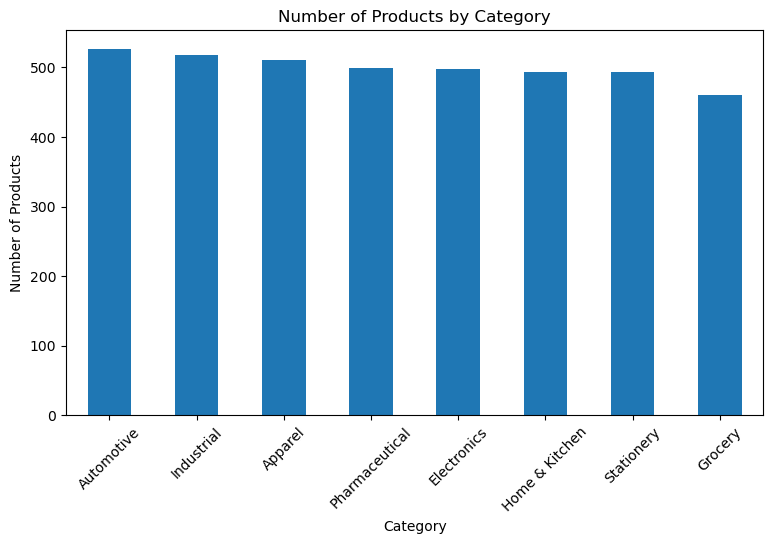

In [11]:
df["category"].value_counts().plot(kind="bar", figsize=(9,5), title="Number of Products by Category")
plt.xlabel("Category"); plt.ylabel("Number of Products"); plt.xticks(rotation=45); plt.show()

### Interpretation
The dataset contains products across multiple categories. The category distribution is suitable for category-level comparisons.

## Question 1

**How does average monthly demand vary across different product categories?**

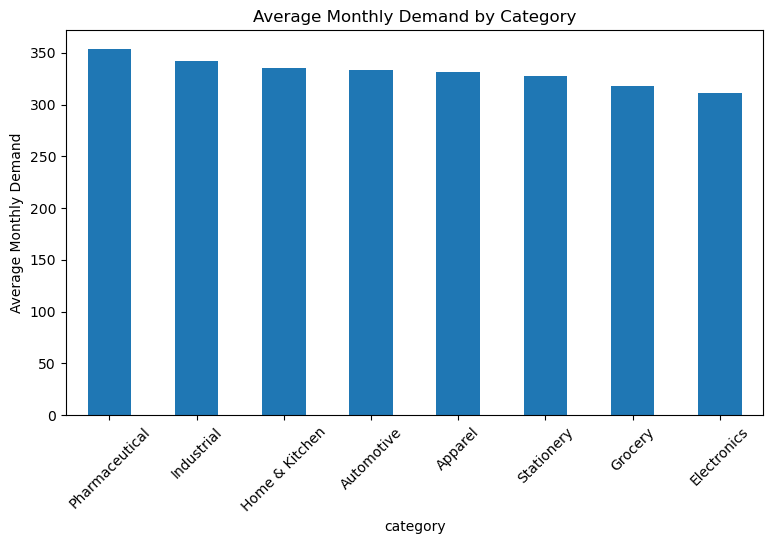

category
Pharmaceutical    354.012024
Industrial        342.108108
Home & Kitchen    335.700405
Automotive        333.521822
Apparel           331.339216
Stationery        327.657895
Grocery           317.458696
Electronics       311.032129
Name: avg_monthly_demand, dtype: float64

In [12]:
# 1. How does average monthly demand vary across different product categories?
category_demand=df.groupby("category")["avg_monthly_demand"].mean().sort_values(ascending=False)
category_demand.plot(kind="bar",figsize=(9,5),title="Average Monthly Demand by Category"); plt.ylabel("Average Monthly Demand"); plt.xticks(rotation=45); plt.show()
category_demand

### Interpretation
Demand differs across categories. The highest average monthly demand is in Pharmaceutical (about 354.01), while Electronics is lowest (about 311.03). Category-specific demand planning is therefore appropriate.

## Question 2

**Which product categories show the highest demand variability?**

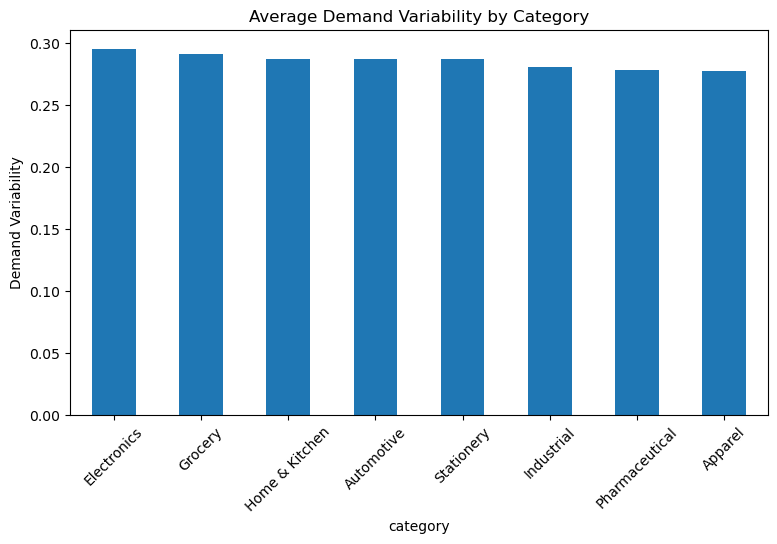

category
Electronics       0.295663
Grocery           0.291500
Home & Kitchen    0.287652
Automotive        0.287173
Stationery        0.287045
Industrial        0.280637
Pharmaceutical    0.278337
Apparel           0.277902
Name: demand_variability, dtype: float64

In [13]:
# 2. Which product categories show the highest demand variability?
category_variability=df.groupby("category")["demand_variability"].mean().sort_values(ascending=False)
category_variability.plot(kind="bar",figsize=(9,5),title="Average Demand Variability by Category"); plt.ylabel("Demand Variability"); plt.xticks(rotation=45); plt.show()
category_variability

### Interpretation
Electronics has the highest average demand variability (about 0.296), followed by Grocery (about 0.292). These categories may require stronger forecasting and safety-stock planning.

## Question 3

**Which warehouse zones handle products with the highest average demand?**

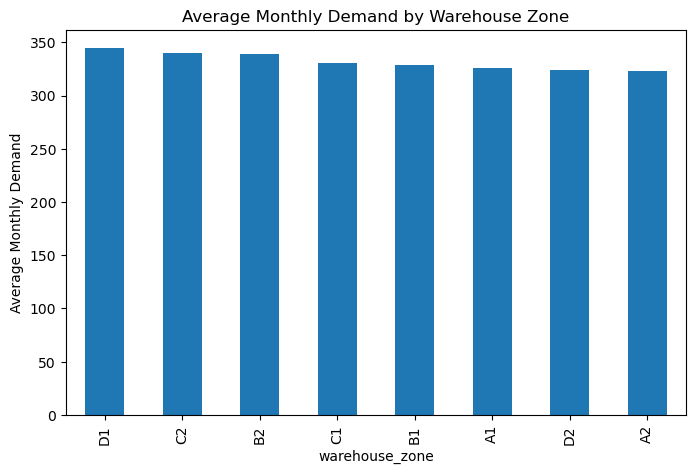

warehouse_zone
D1    344.346939
C2    340.298805
B2    338.925847
C1    330.073260
B1    328.317719
A1    325.836327
D2    324.181633
A2    323.202756
Name: avg_monthly_demand, dtype: float64

In [14]:
# 3. Which warehouse zones handle products with the highest average demand?
zone_demand=df.groupby("warehouse_zone")["avg_monthly_demand"].mean().sort_values(ascending=False)
zone_demand.plot(kind="bar",figsize=(8,5),title="Average Monthly Demand by Warehouse Zone"); plt.ylabel("Average Monthly Demand"); plt.show()
zone_demand

### Interpretation
Zone D1 has the highest average monthly demand (about 344.35 units/month), suggesting greater replenishment and capacity-planning needs.

## Question 4

**Which products have the longest average supplier lead times?**

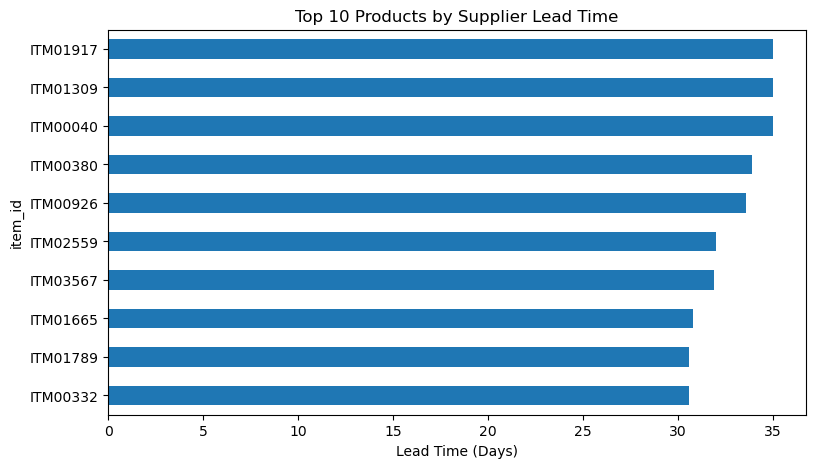

,item_id,category,warehouse_zone,avg_lead_time_days
39,ITM00040,Industrial,D2,35.0
1308,ITM01309,Apparel,C2,35.0
1916,ITM01917,Apparel,B1,35.0
379,ITM00380,Pharmaceutical,B1,33.9
925,ITM00926,Pharmaceutical,B1,33.6
2558,ITM02559,Stationery,D1,32.0
3566,ITM03567,Apparel,A2,31.9
1664,ITM01665,Home & Kitchen,B1,30.8
331,ITM00332,Stationery,D2,30.6
1788,ITM01789,Industrial,D1,30.6


In [15]:
# 4. Which products have the longest average supplier lead times?
top=df.nlargest(10,"avg_lead_time_days")[["item_id","category","warehouse_zone","avg_lead_time_days"]]
top.sort_values("avg_lead_time_days").plot(kind="barh",x="item_id",y="avg_lead_time_days",figsize=(9,5),legend=False,title="Top 10 Products by Supplier Lead Time"); plt.xlabel("Lead Time (Days)"); plt.show()
top

### Interpretation
The longest lead times reach about 35 days, including ITM00040, ITM01309, and ITM01917. Such products require earlier replenishment planning.

## Question 5

**Is high lead-time variability associated with more supplier delay incidents?**

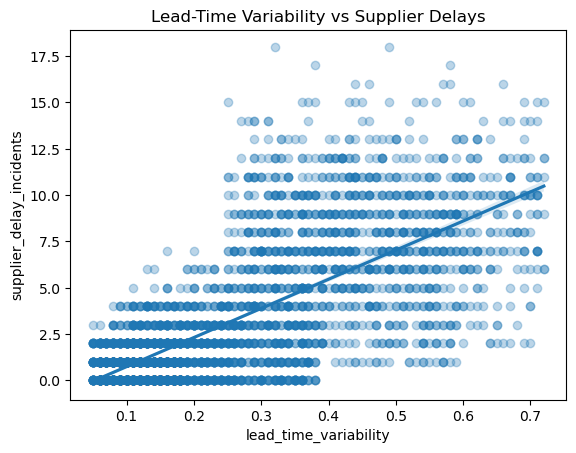

,Correlation
0,0.720934


In [16]:
# 5. Is high lead-time variability associated with more supplier delay incidents?
corr=df["lead_time_variability"].corr(df["supplier_delay_incidents"])
sns.regplot(data=df,x="lead_time_variability",y="supplier_delay_incidents",scatter_kws={"alpha":0.3}); plt.title("Lead-Time Variability vs Supplier Delays"); plt.show()
pd.DataFrame({"Correlation":[corr]})

### Interpretation
The correlation is about 0.721, indicating a strong positive relationship: higher lead-time variability tends to accompany more supplier delay incidents.

## Question 6

**Which products have the highest stock turnover ratios?**

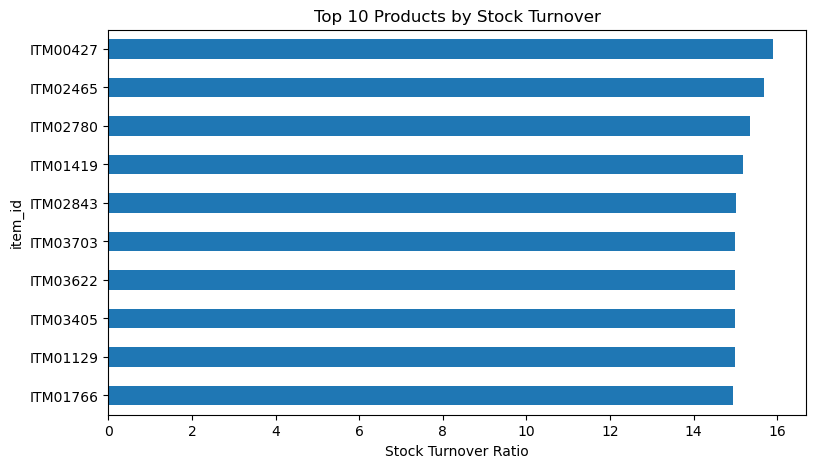

,item_id,category,warehouse_zone,stock_turnover_ratio
426,ITM00427,Apparel,A1,15.89
2464,ITM02465,Electronics,D2,15.69
2779,ITM02780,Grocery,D1,15.34
1418,ITM01419,Industrial,B2,15.18
2842,ITM02843,Stationery,C1,15.01
1128,ITM01129,Apparel,A1,15.00
3404,ITM03405,Automotive,A2,15.00
3621,ITM03622,Stationery,C2,15.00
3702,ITM03703,Industrial,C2,15.00
1765,ITM01766,Home & Kitchen,B1,14.94


In [17]:
# 6. Which products have the highest stock turnover ratios?
top=df.nlargest(10,"stock_turnover_ratio")[["item_id","category","warehouse_zone","stock_turnover_ratio"]]
top.sort_values("stock_turnover_ratio").plot(kind="barh",x="item_id",y="stock_turnover_ratio",figsize=(9,5),legend=False,title="Top 10 Products by Stock Turnover"); plt.xlabel("Stock Turnover Ratio"); plt.show()
top

### Interpretation
The highest turnover ratios include ITM00427 (15.89), ITM02465 (15.69), and ITM02780 (15.34). These products move through inventory quickly.

## Question 7

**Which products remain in inventory for the longest number of days?**

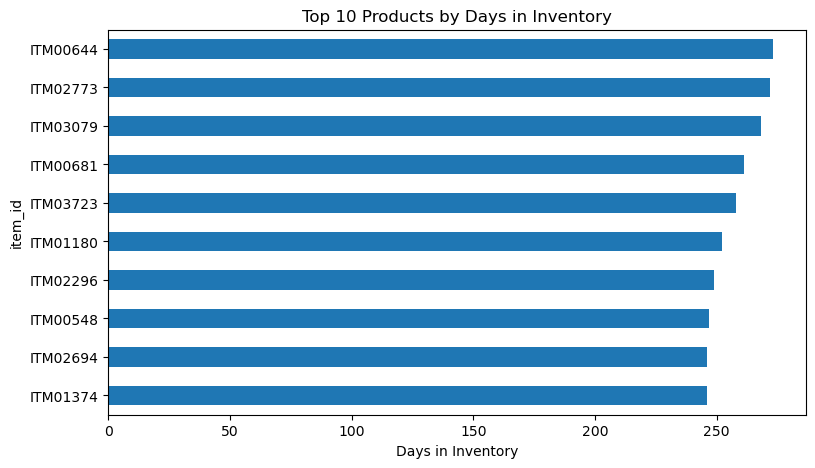

,item_id,category,warehouse_zone,days_in_inventory
643,ITM00644,Industrial,C1,273
2772,ITM02773,Electronics,B2,272
3078,ITM03079,Electronics,A1,268
680,ITM00681,Pharmaceutical,A1,261
3722,ITM03723,Apparel,A2,258
1179,ITM01180,Apparel,A1,252
2295,ITM02296,Apparel,C1,249
547,ITM00548,Electronics,B2,247
1373,ITM01374,Grocery,D1,246
2693,ITM02694,Industrial,D1,246


In [18]:
# 7. Which products remain in inventory for the longest number of days?
top=df.nlargest(10,"days_in_inventory")[["item_id","category","warehouse_zone","days_in_inventory"]]
top.sort_values("days_in_inventory").plot(kind="barh",x="item_id",y="days_in_inventory",figsize=(9,5),legend=False,title="Top 10 Products by Days in Inventory"); plt.xlabel("Days in Inventory"); plt.show()
top

### Interpretation
ITM00644 (273 days) and ITM02773 (272 days) are among the products with the longest inventory duration. These products may be slow-moving.

## Question 8

**Is there a relationship between stock turnover ratio and days in inventory?**

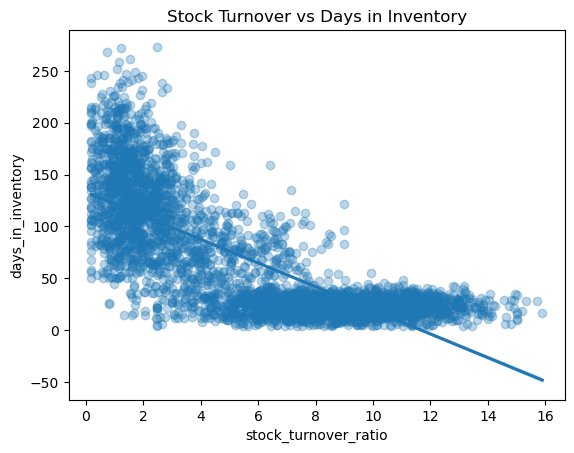

,Correlation
0,-0.76298


In [19]:
# 8. Is there a relationship between stock turnover ratio and days in inventory?
corr=df["stock_turnover_ratio"].corr(df["days_in_inventory"])
sns.regplot(data=df,x="stock_turnover_ratio",y="days_in_inventory",scatter_kws={"alpha":0.3}); plt.title("Stock Turnover vs Days in Inventory"); plt.show()
pd.DataFrame({"Correlation":[corr]})

### Interpretation
The correlation is about -0.763, a strong negative relationship. Higher turnover generally corresponds to fewer days in inventory.

## Question 9

**Which products experience the highest stockout frequency?**

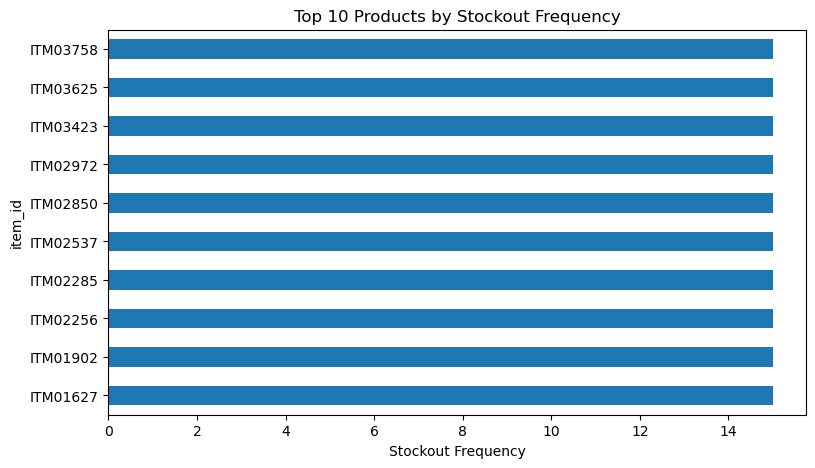

,item_id,category,warehouse_zone,stockout_frequency
1626,ITM01627,Home & Kitchen,B2,15
1901,ITM01902,Home & Kitchen,C2,15
2255,ITM02256,Grocery,A1,15
2284,ITM02285,Apparel,C1,15
2536,ITM02537,Stationery,B2,15
2849,ITM02850,Home & Kitchen,C1,15
2971,ITM02972,Home & Kitchen,A2,15
3422,ITM03423,Stationery,B1,15
3624,ITM03625,Automotive,C2,15
3757,ITM03758,Stationery,C1,15


In [20]:
# 9. Which products experience the highest stockout frequency?
top=df.nlargest(10,"stockout_frequency")[["item_id","category","warehouse_zone","stockout_frequency"]]
top.sort_values("stockout_frequency").plot(kind="barh",x="item_id",y="stockout_frequency",figsize=(9,5),legend=False,title="Top 10 Products by Stockout Frequency"); plt.xlabel("Stockout Frequency"); plt.show()
top

### Interpretation
The maximum stockout frequency is 15 incidents. Products at this level should receive priority in replenishment and safety-stock review.

## Question 10

**Are products with high demand variability more likely to experience stockouts?**

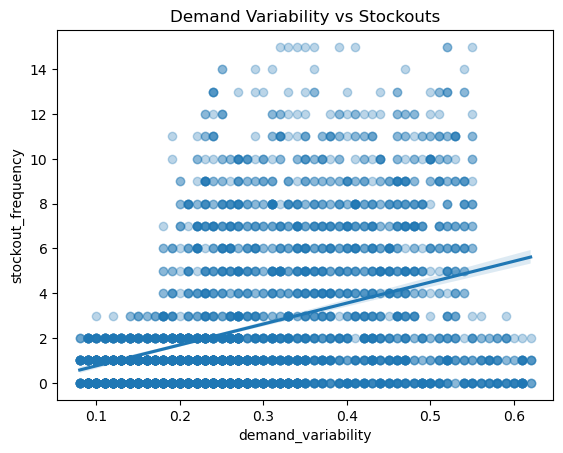

,Correlation
0,0.374789


In [21]:
# 10. Are products with high demand variability more likely to experience stockouts?
corr=df["demand_variability"].corr(df["stockout_frequency"])
sns.regplot(data=df,x="demand_variability",y="stockout_frequency",scatter_kws={"alpha":0.3}); plt.title("Demand Variability vs Stockouts"); plt.show()
pd.DataFrame({"Correlation":[corr]})

### Interpretation
The correlation is about 0.375, a moderate positive relationship. Higher demand variability is associated with more stockouts, although other factors also matter.

## Question 11

**Which products experience frequent backorders?**

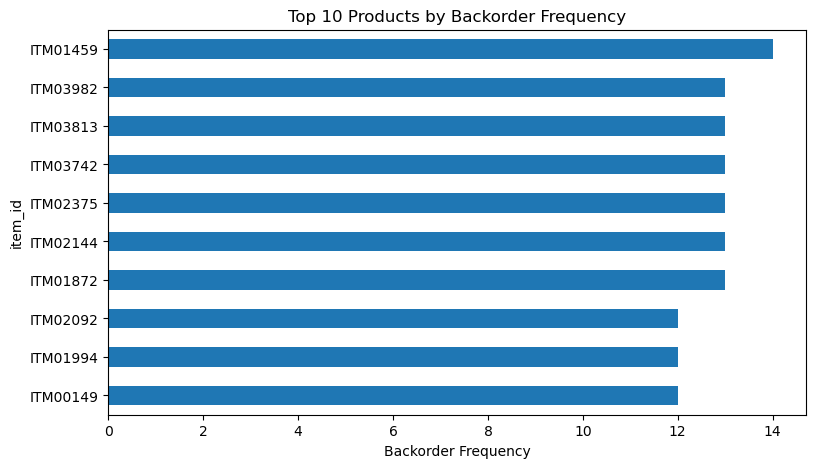

,item_id,category,warehouse_zone,backorder_frequency
1458,ITM01459,Home & Kitchen,C1,14
1871,ITM01872,Stationery,C1,13
2143,ITM02144,Grocery,D2,13
2374,ITM02375,Automotive,A2,13
3741,ITM03742,Industrial,A1,13
3812,ITM03813,Pharmaceutical,C1,13
3981,ITM03982,Pharmaceutical,C2,13
148,ITM00149,Industrial,A1,12
1993,ITM01994,Electronics,A2,12
2091,ITM02092,Grocery,A2,12


In [22]:
# 11. Which products experience frequent backorders?
top=df.nlargest(10,"backorder_frequency")[["item_id","category","warehouse_zone","backorder_frequency"]]
top.sort_values("backorder_frequency").plot(kind="barh",x="item_id",y="backorder_frequency",figsize=(9,5),legend=False,title="Top 10 Products by Backorder Frequency"); plt.xlabel("Backorder Frequency"); plt.show()
top

### Interpretation
The maximum backorder frequency is 14 incidents. These products indicate repeated difficulty in satisfying demand from available stock.

## Question 12

**Is backorder frequency associated with stockout frequency?**

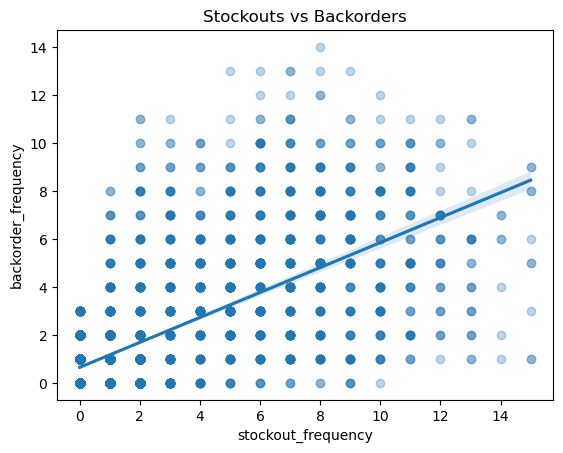

,Correlation
0,0.663003


In [23]:
# 12. Is backorder frequency associated with stockout frequency?
corr=df["backorder_frequency"].corr(df["stockout_frequency"])
sns.regplot(data=df,x="stockout_frequency",y="backorder_frequency",scatter_kws={"alpha":0.3}); plt.title("Stockouts vs Backorders"); plt.show()
pd.DataFrame({"Correlation":[corr]})

### Interpretation
The correlation is about 0.663, showing a moderate-to-strong positive relationship between stockouts and backorders.

## Question 13

**Which products have the highest reorder-point breaches?**

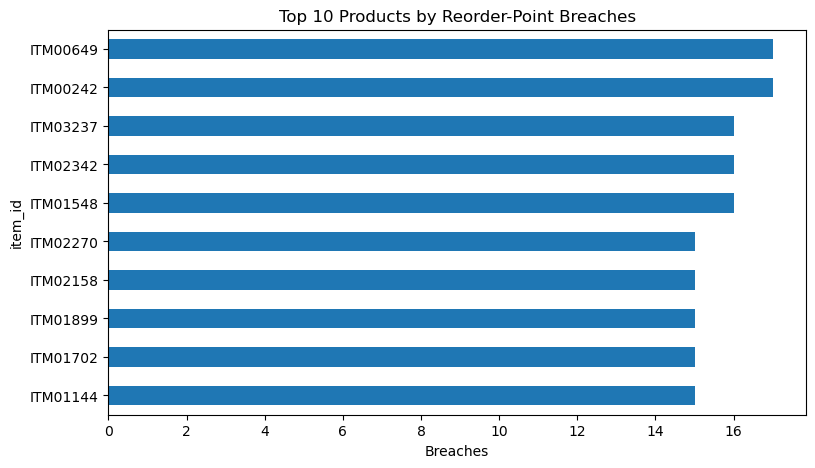

,item_id,category,warehouse_zone,reorder_point_breaches
241,ITM00242,Pharmaceutical,C1,17
648,ITM00649,Stationery,A1,17
1547,ITM01548,Apparel,D1,16
2341,ITM02342,Automotive,C1,16
3236,ITM03237,Apparel,C1,16
1143,ITM01144,Industrial,D1,15
1701,ITM01702,Industrial,D2,15
1898,ITM01899,Pharmaceutical,D1,15
2157,ITM02158,Electronics,D2,15
2269,ITM02270,Stationery,A2,15


In [24]:
# 13. Which products have the highest reorder-point breaches?
top=df.nlargest(10,"reorder_point_breaches")[["item_id","category","warehouse_zone","reorder_point_breaches"]]
top.sort_values("reorder_point_breaches").plot(kind="barh",x="item_id",y="reorder_point_breaches",figsize=(9,5),legend=False,title="Top 10 Products by Reorder-Point Breaches"); plt.xlabel("Breaches"); plt.show()
top

### Interpretation
The maximum number of reorder-point breaches is 17. Products with repeated breaches should be reviewed for replenishment timing and reorder-point settings.

## Question 14

**Do products with frequent reorder-point breaches also have high monthly reorder counts?**

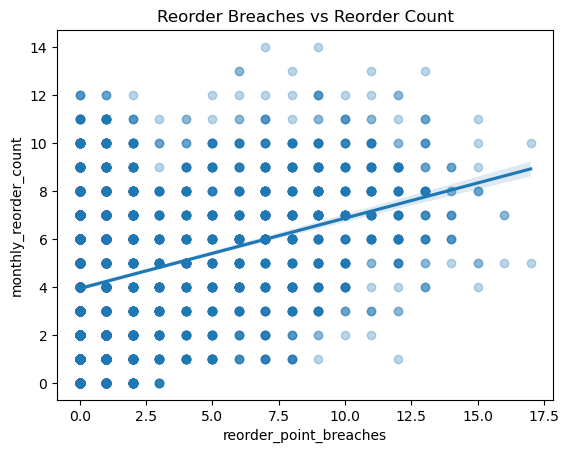

,Correlation
0,0.342835


In [25]:
# 14. Do products with frequent reorder-point breaches also have high monthly reorder counts?
corr=df["reorder_point_breaches"].corr(df["monthly_reorder_count"])
sns.regplot(data=df,x="reorder_point_breaches",y="monthly_reorder_count",scatter_kws={"alpha":0.3}); plt.title("Reorder Breaches vs Reorder Count"); plt.show()
pd.DataFrame({"Correlation":[corr]})

### Interpretation
The correlation is about 0.343, indicating a moderate positive relationship. More reorder-point breaches tend to accompany more reorder activity.

## Question 15

**Which products have the highest supplier delay incidents?**

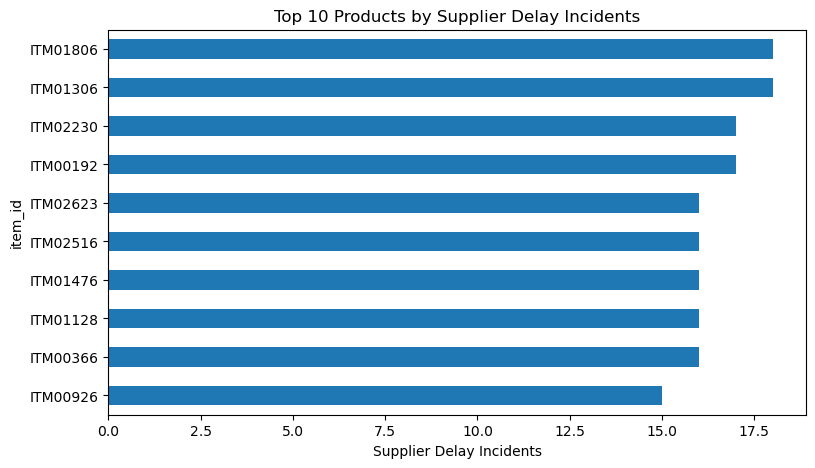

,item_id,category,warehouse_zone,supplier_delay_incidents
1305,ITM01306,Stationery,C2,18
1805,ITM01806,Automotive,A2,18
191,ITM00192,Apparel,D1,17
2229,ITM02230,Apparel,C2,17
365,ITM00366,Automotive,D1,16
1127,ITM01128,Automotive,A2,16
1475,ITM01476,Grocery,B2,16
2515,ITM02516,Grocery,A1,16
2622,ITM02623,Grocery,C2,16
925,ITM00926,Pharmaceutical,B1,15


In [26]:
# 15. Which products have the highest supplier delay incidents?
top=df.nlargest(10,"supplier_delay_incidents")[["item_id","category","warehouse_zone","supplier_delay_incidents"]]
top.sort_values("supplier_delay_incidents").plot(kind="barh",x="item_id",y="supplier_delay_incidents",figsize=(9,5),legend=False,title="Top 10 Products by Supplier Delay Incidents"); plt.xlabel("Supplier Delay Incidents"); plt.show()
top

### Interpretation
The maximum supplier delay frequency is 18 incidents. These products require closer supplier-performance monitoring.

## Question 16

**Is supplier delay associated with increased stockouts or backorders?**

In [27]:
# 16. Is supplier delay associated with increased stockouts or backorders?
corrs=pd.DataFrame({"Relationship":["Supplier delays vs stockouts","Supplier delays vs backorders"],"Correlation":[df["supplier_delay_incidents"].corr(df["stockout_frequency"]),df["supplier_delay_incidents"].corr(df["backorder_frequency"])]})
corrs

,Relationship,Correlation
0,Supplier delays vs stockouts,0.610335
1,Supplier delays vs backorders,0.569561


### Interpretation
Supplier delays correlate positively with stockouts (about 0.610) and backorders (about 0.570). Supplier reliability is therefore important for product availability.

## Question 17

**Which products maintain significantly higher safety stock relative to their current stock?**

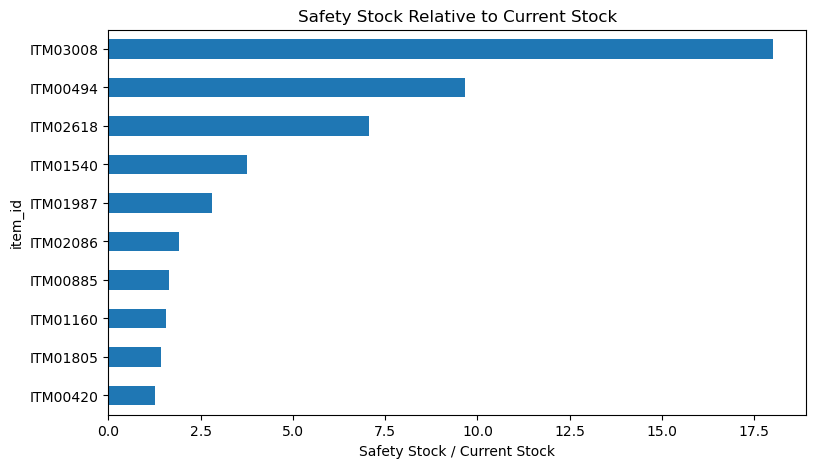

,item_id,category,current_stock,safety_stock,safety_stock_ratio
3007,ITM03008,Home & Kitchen,1,18,18.000000
493,ITM00494,Home & Kitchen,3,29,9.666667
2617,ITM02618,Pharmaceutical,20,141,7.050000
1539,ITM01540,Home & Kitchen,4,15,3.750000
1986,ITM01987,Apparel,38,107,2.815789
2085,ITM02086,Automotive,24,46,1.916667
884,ITM00885,Stationery,54,88,1.629630
1159,ITM01160,Pharmaceutical,53,83,1.566038
1804,ITM01805,Automotive,107,152,1.420561
419,ITM00420,Industrial,100,125,1.250000


In [28]:
# 17. Which products maintain significantly higher safety stock relative to their current stock?
x=df[df["current_stock"]>0].copy(); x["safety_stock_ratio"]=x["safety_stock"]/x["current_stock"]; top=x.nlargest(10,"safety_stock_ratio")[["item_id","category","current_stock","safety_stock","safety_stock_ratio"]]
top.sort_values("safety_stock_ratio").plot(kind="barh",x="item_id",y="safety_stock_ratio",figsize=(9,5),legend=False,title="Safety Stock Relative to Current Stock"); plt.xlabel("Safety Stock / Current Stock"); plt.show()
top

### Interpretation
ITM03008 has an especially high safety-stock-to-current-stock ratio (18.00×), followed by ITM00494 (9.67×) and ITM02618 (7.05×). These levels should be reviewed against demand and supply risk.

## Question 18

**Which products have high excess-stock levels?**

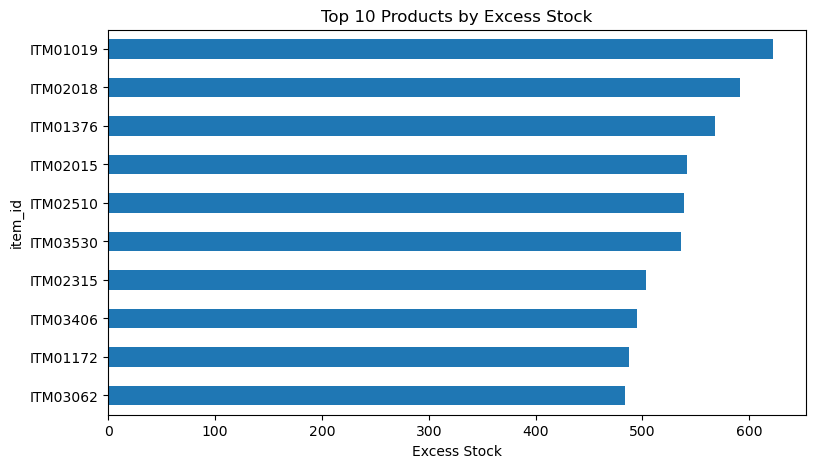

,item_id,category,warehouse_zone,excess_stock_level
1018,ITM01019,Grocery,A2,622
2017,ITM02018,Automotive,B2,591
1375,ITM01376,Grocery,C2,568
2014,ITM02015,Home & Kitchen,A2,542
2509,ITM02510,Stationery,B2,539
3529,ITM03530,Electronics,C2,536
2314,ITM02315,Electronics,D2,503
3405,ITM03406,Stationery,D1,495
1171,ITM01172,Industrial,B1,487
3061,ITM03062,Stationery,C1,484


In [29]:
# 18. Which products have high excess-stock levels?
top=df.nlargest(10,"excess_stock_level")[["item_id","category","warehouse_zone","excess_stock_level"]]
top.sort_values("excess_stock_level").plot(kind="barh",x="item_id",y="excess_stock_level",figsize=(9,5),legend=False,title="Top 10 Products by Excess Stock"); plt.xlabel("Excess Stock"); plt.show()
top

### Interpretation
The highest excess-stock levels include ITM01019 (622 units), ITM02018 (591), and ITM01376 (568). These products are candidates for inventory-reduction review.

## Question 19

**Is excess stock associated with high days in inventory?**

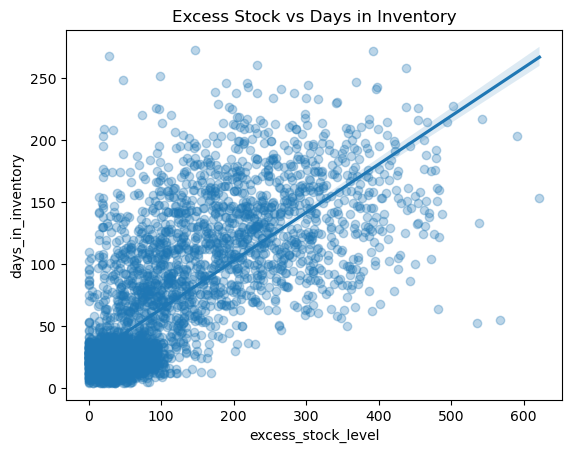

,Correlation
0,0.729002


In [30]:
# 19. Is excess stock associated with high days in inventory?
corr=df["excess_stock_level"].corr(df["days_in_inventory"])
sns.regplot(data=df,x="excess_stock_level",y="days_in_inventory",scatter_kws={"alpha":0.3}); plt.title("Excess Stock vs Days in Inventory"); plt.show()
pd.DataFrame({"Correlation":[corr]})

### Interpretation
The correlation is about 0.729, indicating a strong positive relationship. Higher excess stock tends to be associated with longer inventory duration.

## Question 20

**Which products have the highest inventory value?**

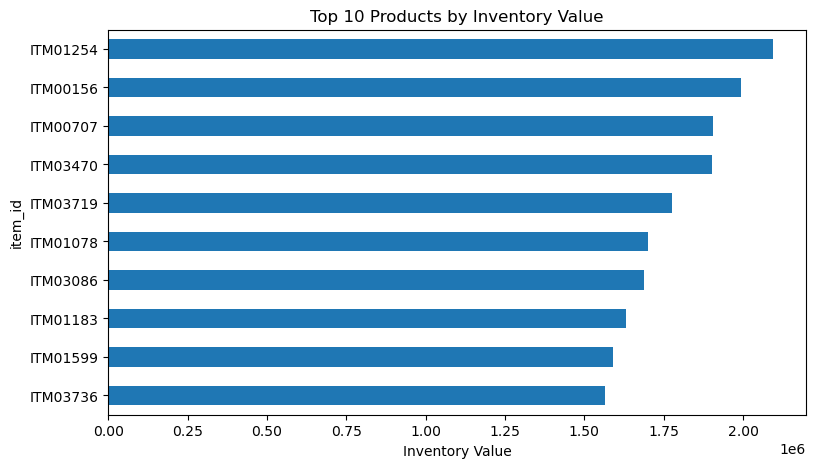

,item_id,category,warehouse_zone,inventory_value
1253,ITM01254,Industrial,D1,2093353.52
155,ITM00156,Industrial,B2,1993974.96
706,ITM00707,Industrial,B1,1905333.80
3469,ITM03470,Industrial,C2,1902986.23
3718,ITM03719,Automotive,D2,1775518.85
1077,ITM01078,Industrial,D1,1699984.38
3085,ITM03086,Industrial,C1,1687486.24
1182,ITM01183,Industrial,B1,1632093.78
1598,ITM01599,Industrial,B1,1590946.24
3735,ITM03736,Industrial,A1,1563724.36


In [31]:
# 20. Which products have the highest inventory value?
top=df.nlargest(10,"inventory_value")[["item_id","category","warehouse_zone","inventory_value"]]
top.sort_values("inventory_value").plot(kind="barh",x="item_id",y="inventory_value",figsize=(9,5),legend=False,title="Top 10 Products by Inventory Value"); plt.xlabel("Inventory Value"); plt.show()
top

### Interpretation
The highest inventory values include ITM01254 (about 2.09 million), ITM00156 (about 1.99 million), and ITM00707 (about 1.91 million). High-value products deserve stronger inventory controls.

## Question 21

**Which products have the highest holding cost per unit?**

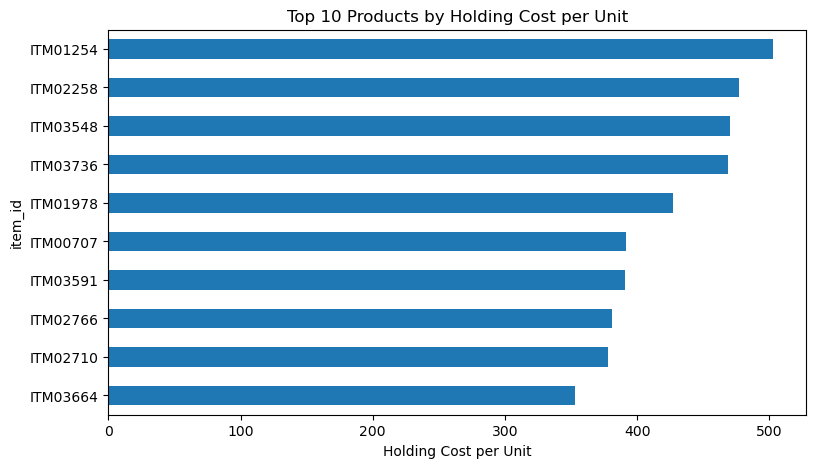

,item_id,category,warehouse_zone,holding_cost_per_unit
1253,ITM01254,Industrial,D1,502.57
2257,ITM02258,Industrial,D1,477.00
3547,ITM03548,Electronics,D2,470.56
3735,ITM03736,Industrial,A1,468.89
1977,ITM01978,Automotive,A1,427.05
706,ITM00707,Industrial,B1,391.89
3590,ITM03591,Industrial,D2,390.88
2765,ITM02766,Industrial,D1,380.79
2709,ITM02710,Industrial,B1,377.69
3663,ITM03664,Industrial,A1,353.22


In [32]:
# 21. Which products have the highest holding cost per unit?
top=df.nlargest(10,"holding_cost_per_unit")[["item_id","category","warehouse_zone","holding_cost_per_unit"]]
top.sort_values("holding_cost_per_unit").plot(kind="barh",x="item_id",y="holding_cost_per_unit",figsize=(9,5),legend=False,title="Top 10 Products by Holding Cost per Unit"); plt.xlabel("Holding Cost per Unit"); plt.show()
top

### Interpretation
The highest holding costs per unit include ITM01254 (502.57), ITM02258 (477.00), and ITM03548 (470.56). These products can create significant carrying costs.

## Question 22

**Do expensive products tend to have lower or higher stock turnover?**

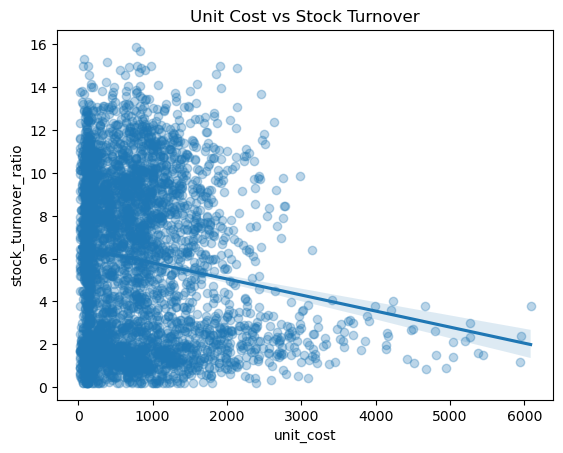

,Correlation
0,-0.146084


In [33]:
# 22. Do expensive products tend to have lower or higher stock turnover?
corr=df["unit_cost"].corr(df["stock_turnover_ratio"])
sns.regplot(data=df,x="unit_cost",y="stock_turnover_ratio",scatter_kws={"alpha":0.3}); plt.title("Unit Cost vs Stock Turnover"); plt.show()
pd.DataFrame({"Correlation":[corr]})

### Interpretation
The correlation is about -0.146, a weak negative relationship. Expensive products tend to have slightly lower turnover, but unit cost alone is not a strong predictor.

## Question 23

**Which products have the highest return rates?**

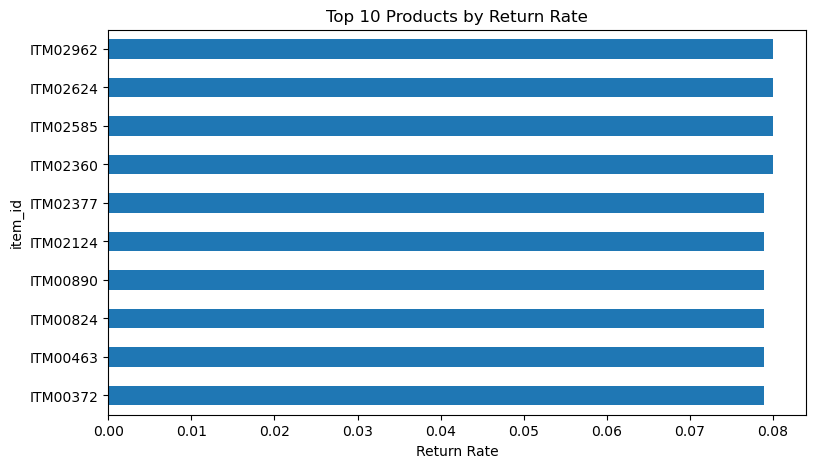

,item_id,category,warehouse_zone,return_rate
2359,ITM02360,Pharmaceutical,D1,0.080
2584,ITM02585,Home & Kitchen,D1,0.080
2623,ITM02624,Grocery,A2,0.080
2961,ITM02962,Stationery,A1,0.080
371,ITM00372,Stationery,A1,0.079
462,ITM00463,Electronics,D1,0.079
823,ITM00824,Home & Kitchen,A1,0.079
889,ITM00890,Home & Kitchen,D1,0.079
2123,ITM02124,Grocery,A1,0.079
2376,ITM02377,Automotive,A1,0.079


In [34]:
# 23. Which products have the highest return rates?
top=df.nlargest(10,"return_rate")[["item_id","category","warehouse_zone","return_rate"]]
top.sort_values("return_rate").plot(kind="barh",x="item_id",y="return_rate",figsize=(9,5),legend=False,title="Top 10 Products by Return Rate"); plt.xlabel("Return Rate"); plt.show()
top

### Interpretation
The maximum return rate is 8%. Products at this level should be investigated for product-quality, packaging, fulfillment, or customer-expectation issues.

## Question 24

**Which products have the highest damage rates?**

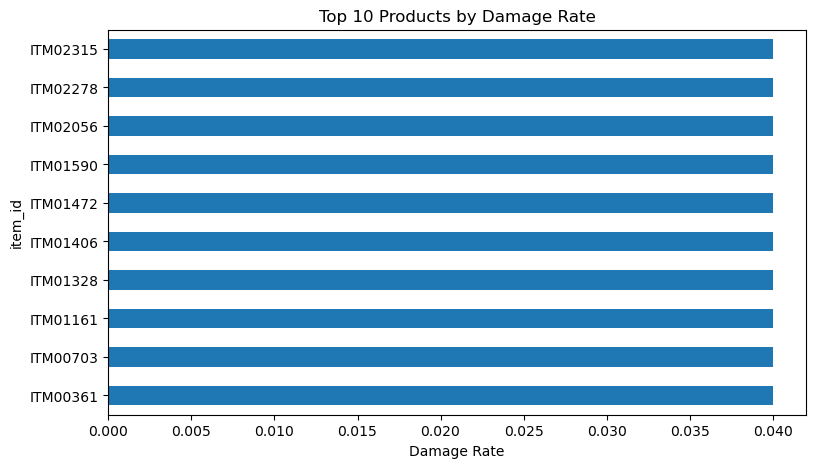

,item_id,category,warehouse_zone,damage_rate
360,ITM00361,Industrial,B1,0.04
702,ITM00703,Electronics,D1,0.04
1160,ITM01161,Pharmaceutical,C2,0.04
1327,ITM01328,Industrial,D1,0.04
1405,ITM01406,Industrial,C2,0.04
1471,ITM01472,Pharmaceutical,B1,0.04
1589,ITM01590,Stationery,C2,0.04
2055,ITM02056,Pharmaceutical,A2,0.04
2277,ITM02278,Home & Kitchen,A2,0.04
2314,ITM02315,Electronics,D2,0.04


In [35]:
# 24. Which products have the highest damage rates?
top=df.nlargest(10,"damage_rate")[["item_id","category","warehouse_zone","damage_rate"]]
top.sort_values("damage_rate").plot(kind="barh",x="item_id",y="damage_rate",figsize=(9,5),legend=False,title="Top 10 Products by Damage Rate"); plt.xlabel("Damage Rate"); plt.show()
top

### Interpretation
The maximum damage rate is 4%. Products at this level should be checked for packaging, handling, storage, and transportation issues.

## Question 25

**Are high return and damage rates concentrated in particular categories or warehouse zones?**

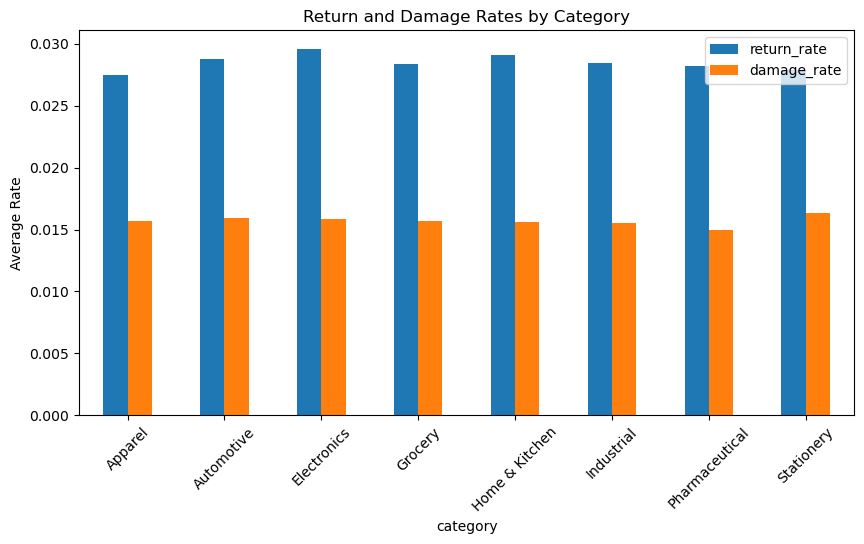

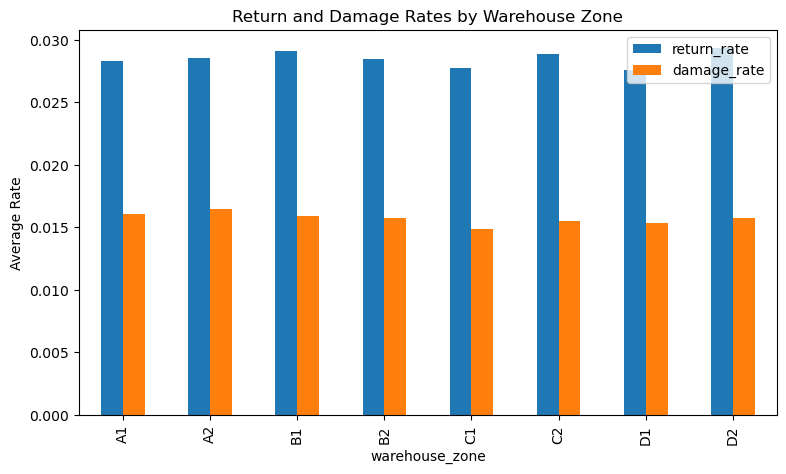

return_rate  damage_rate
Category       Apparel            0.027494     0.015663
               Automotive         0.028767     0.015972
               Electronics        0.029620     0.015857
               Grocery            0.028346     0.015689
               Home & Kitchen     0.029095     0.015636
               Industrial         0.028432     0.015564
               Pharmaceutical     0.028216     0.014996
               Stationery         0.027907     0.016324
Warehouse Zone A1                 0.028317     0.016032
               A2                 0.028528     0.016478
               B1                 0.029092     0.015939
               B2                 0.028460     0.015769
               C1                 0.027777     0.014905
               C2                 0.028894     0.015542
               D1                 0.027563     0.015376
               D2                 0.029318     0.015727

In [36]:
# 25. Are high return and damage rates concentrated in particular categories or warehouse zones?
cat=df.groupby("category")[["return_rate","damage_rate"]].mean(); zone=df.groupby("warehouse_zone")[["return_rate","damage_rate"]].mean()
cat.plot(kind="bar",figsize=(10,5),title="Return and Damage Rates by Category"); plt.ylabel("Average Rate"); plt.xticks(rotation=45); plt.show()
zone.plot(kind="bar",figsize=(9,5),title="Return and Damage Rates by Warehouse Zone"); plt.ylabel("Average Rate"); plt.show()
pd.concat({"Category":cat,"Warehouse Zone":zone})

### Interpretation
Electronics has the highest average return rate (about 2.96%), while Stationery has the highest average damage rate (about 1.63%). D2 has the highest average return rate by zone (about 2.93%), while A2 has the highest average damage rate (about 1.65%).

## Question 26

**Which products have the highest warehouse demand pressure index?**

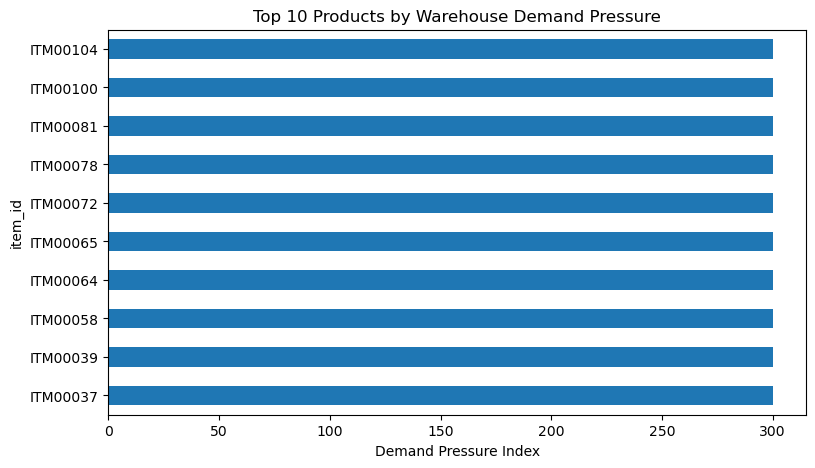

,item_id,category,warehouse_zone,warehouse_demand_pressure_index
36,ITM00037,Grocery,B1,300.0
38,ITM00039,Pharmaceutical,B1,300.0
57,ITM00058,Pharmaceutical,D2,300.0
63,ITM00064,Industrial,D2,300.0
64,ITM00065,Stationery,A1,300.0
71,ITM00072,Automotive,C1,300.0
77,ITM00078,Industrial,B2,300.0
80,ITM00081,Industrial,B2,300.0
99,ITM00100,Grocery,D1,300.0
103,ITM00104,Automotive,C1,300.0


In [37]:
# 26. Which products have the highest warehouse demand pressure index?
top=df.nlargest(10,"warehouse_demand_pressure_index")[["item_id","category","warehouse_zone","warehouse_demand_pressure_index"]]
top.sort_values("warehouse_demand_pressure_index").plot(kind="barh",x="item_id",y="warehouse_demand_pressure_index",figsize=(9,5),legend=False,title="Top 10 Products by Warehouse Demand Pressure"); plt.xlabel("Demand Pressure Index"); plt.show()
top

### Interpretation
The maximum warehouse demand pressure index is 300. Products reaching this maximum should receive additional attention in warehouse capacity and replenishment planning.

# Final Business Insights

- Demand differs across categories, with Pharmaceutical showing the highest average monthly demand.
- Electronics has the highest demand variability, indicating a greater forecasting challenge.
- Zone D1 handles the highest average demand.
- Lead-time variability has a strong positive association with supplier delay incidents.
- Stock turnover has a strong negative association with days in inventory.
- Demand variability is positively associated with stockouts.
- Stockouts and backorders are positively associated.
- Supplier delays are positively associated with stockouts and backorders.
- Excess stock is strongly associated with longer inventory duration.
- Some products carry very high inventory values and holding costs and should be closely monitored.
- Return and damage rates show some category and zone differences.
- Products at the maximum warehouse demand pressure index should receive additional operational attention.

# Conclusion

The dataset is clean, containing **4,000 records, 25 columns, 0 missing values, and 0 duplicate rows**. The analysis shows that demand planning, supplier reliability, replenishment policy, inventory turnover, excess stock, and product quality are all important aspects of warehouse performance.

The findings can support demand forecasting, safety-stock optimization, supplier monitoring, stockout reduction, excess-inventory reduction, warehouse capacity planning, and inventory-cost management.

**Note:** Correlation measures association and does not by itself prove causation.

# K-Means Clustering

## Objective

The next stage of the project uses **K-Means clustering** to segment products into groups with similar warehouse inventory characteristics.

The clustering workflow follows the structure demonstrated in class:

1. Create a copy of the dataframe.
2. Drop identifier columns.
3. Separate numerical and categorical columns.
4. Encode categorical columns.
5. Standard-scale numerical columns.
6. Save the processed data in the copied dataframe.
7. Create the feature matrix `X`.
8. Calculate WCSS for different values of K.
9. Use the Elbow Method to select the number of clusters.
10. Train K-Means.
11. Add cluster labels.
12. Analyze the characteristics of each cluster.
13. Use PCA for two-dimensional visualization.
14. Interpret the resulting inventory segments.

### Important preprocessing decision

The columns such as `avg_monthly_demand`, `demand_variability`, `avg_lead_time_days`, `stock_turnover_ratio`, and `inventory_value` are **numerical**, so they are standardized rather than label-encoded.

The categorical columns are `category`, `subcategory`, and `warehouse_zone`. These are converted to numerical dummy variables using one-hot encoding.

`item_id` and `supplier_id` are identifiers and are therefore removed from the clustering features.

### Clustering Data Structure

| Variable type | Treatment |
|---|---|
| `item_id`, `supplier_id` | Drop |
| `category`, `subcategory`, `warehouse_zone` | One-hot encoding |
| Demand, lead-time, stock, cost, quality and pressure variables | StandardScaler |
| Target variable | None — unsupervised learning |

The dataset contains 4,000 product records and 25 original columns. The available variables include demand, supplier, inventory, cost, quality, and warehouse-pressure measures.

## Create a Copy of the DataFrame

In [38]:
# 1. Create a copy of the dataframe

df1 = df.copy()

df1.head()

,item_id,category,subcategory,supplier_id,warehouse_zone,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,...,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
0,ITM00001,Grocery,Snacks,S1036,B2,310,0.26,7.8,0.05,8,...,0.012,10.83,132.98,1,2,249,75,46,33112.02,161.12
1,ITM00002,Industrial,Electrical Parts,S1036,B1,455,0.16,4.8,0.08,8,...,0.007,45.57,1525.56,0,0,362,94,34,552252.72,141.27
2,ITM00003,Apparel,Jackets,S1011,B2,350,0.43,20.9,0.57,6,...,0.010,18.47,457.56,3,9,317,105,146,145046.52,238.29
3,ITM00004,Automotive,Lubricants,S1030,A1,121,0.33,4.6,0.12,1,...,0.017,168.71,1779.38,0,1,183,32,84,325626.54,87.90
4,ITM00005,Pharmaceutical,Medical Devices,S1064,A2,85,0.14,7.3,0.15,1,...,0.016,33.33,731.83,2,4,209,17,180,152952.47,86.85


### Interpretation

A separate copy of the original dataframe is created so that clustering preprocessing does not alter the original analysis dataframe.

## Drop the ID Columns

In [39]:
# 2. Drop the ID columns

drop_columns = ["item_id", "supplier_id"]

df_dropped = df1.drop(columns=drop_columns)

df_dropped.head()

,category,subcategory,warehouse_zone,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,days_in_inventory,...,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
0,Grocery,Snacks,B2,310,0.26,7.8,0.05,8,9.71,33,...,0.012,10.83,132.98,1,2,249,75,46,33112.02,161.12
1,Industrial,Electrical Parts,B1,455,0.16,4.8,0.08,8,11.55,26,...,0.007,45.57,1525.56,0,0,362,94,34,552252.72,141.27
2,Apparel,Jackets,B2,350,0.43,20.9,0.57,6,3.69,27,...,0.010,18.47,457.56,3,9,317,105,146,145046.52,238.29
3,Automotive,Lubricants,A1,121,0.33,4.6,0.12,1,0.54,120,...,0.017,168.71,1779.38,0,1,183,32,84,325626.54,87.90
4,Pharmaceutical,Medical Devices,A2,85,0.14,7.3,0.15,1,1.46,97,...,0.016,33.33,731.83,2,4,209,17,180,152952.47,86.85


### Interpretation

`item_id` and `supplier_id` are identifiers rather than meaningful measures of product similarity. They are removed so that K-Means does not create clusters based on arbitrary ID values.

## Separate Numerical and Categorical Columns

In [40]:
# 3. Separate numerical and categorical columns

categorical_cols = [
    "category",
    "subcategory",
    "warehouse_zone"
]

numerical_cols = [
    "avg_monthly_demand",
    "demand_variability",
    "avg_lead_time_days",
    "lead_time_variability",
    "monthly_reorder_count",
    "stock_turnover_ratio",
    "days_in_inventory",
    "stockout_frequency",
    "backorder_frequency",
    "return_rate",
    "damage_rate",
    "holding_cost_per_unit",
    "unit_cost",
    "reorder_point_breaches",
    "supplier_delay_incidents",
    "current_stock",
    "safety_stock",
    "excess_stock_level",
    "inventory_value",
    "warehouse_demand_pressure_index"
]

categorical_cols, numerical_cols

(['category', 'subcategory', 'warehouse_zone'],
 ['avg_monthly_demand',
  'demand_variability',
  'avg_lead_time_days',
  'lead_time_variability',
  'monthly_reorder_count',
  'stock_turnover_ratio',
  'days_in_inventory',
  'stockout_frequency',
  'backorder_frequency',
  'return_rate',
  'damage_rate',
  'holding_cost_per_unit',
  'unit_cost',
  'reorder_point_breaches',
  'supplier_delay_incidents',
  'current_stock',
  'safety_stock',
  'excess_stock_level',
  'inventory_value',
  'warehouse_demand_pressure_index'])

### Interpretation

The variables are separated according to their data type. Product category, subcategory, and warehouse zone are categorical, while demand, supplier, inventory, cost, quality, and warehouse-pressure measures are numerical.

## Encode the Categorical Columns

In [41]:
# 4. Encode the categorical columns using one-hot encoding

df_encoded = pd.get_dummies(
    df_dropped,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

df_encoded.head()

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,days_in_inventory,stockout_frequency,backorder_frequency,return_rate,...,subcategory_T-Shirts,subcategory_Tools,subcategory_Writing Tools,warehouse_zone_A2,warehouse_zone_B1,warehouse_zone_B2,warehouse_zone_C1,warehouse_zone_C2,warehouse_zone_D1,warehouse_zone_D2
0,310,0.26,7.8,0.05,8,9.71,33,1,1,0.028,...,0,0,0,0,0,1,0,0,0,0
1,455,0.16,4.8,0.08,8,11.55,26,2,2,0.008,...,0,0,0,0,1,0,0,0,0,0
2,350,0.43,20.9,0.57,6,3.69,27,8,5,0.030,...,0,0,0,0,0,1,0,0,0,0
3,121,0.33,4.6,0.12,1,0.54,120,0,0,0.009,...,0,0,0,0,0,0,0,0,0,0
4,85,0.14,7.3,0.15,1,1.46,97,0,2,0.033,...,0,0,0,1,0,0,0,0,0,0


### Interpretation

The categorical variables are converted into numerical dummy variables so that K-Means can use them. `drop_first=True` removes one reference category from each categorical variable and avoids redundant dummy columns.

## Apply Standard Scaler on Numerical Columns

In [45]:
# 5. Apply standard scaler on numerical columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_encoded[numerical_cols])

df_encoded[numerical_cols] = X_scaled

df_encoded.head()

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,days_in_inventory,stockout_frequency,backorder_frequency,return_rate,...,subcategory_T-Shirts,subcategory_Tools,subcategory_Writing Tools,warehouse_zone_A2,warehouse_zone_B1,warehouse_zone_B2,warehouse_zone_C1,warehouse_zone_C2,warehouse_zone_D1,warehouse_zone_D2
0,-0.095483,-0.200067,-0.447313,-1.257892,1.100980,0.990039,-0.571515,-0.467171,-0.374701,-0.031157,...,0,0,0,0,0,1,0,0,0,0
1,0.539341,-0.980359,-0.983816,-1.077107,1.100980,1.473790,-0.694650,-0.153896,0.024767,-1.316640,...,0,0,0,0,1,0,0,0,0,0
2,0.079641,1.126430,1.895414,1.875728,0.432250,-0.592670,-0.677059,1.725751,1.223171,0.097391,...,0,0,0,0,0,1,0,0,0,0
3,-0.922943,0.346138,-1.019583,-0.836059,-1.239575,-1.420831,0.958870,-0.780445,-0.774169,-1.252366,...,0,0,0,0,0,0,0,0,0,0
4,-1.080555,-1.136418,-0.536730,-0.655273,-1.239575,-1.178955,0.554285,-0.780445,0.024767,0.290214,...,0,0,0,1,0,0,0,0,0,0


### Interpretation

StandardScaler puts the numerical variables on a comparable scale. This is especially important for K-Means because variables such as inventory value have much larger numerical magnitudes than variables such as return rate. Without scaling, large-valued variables could dominate the distance calculations.

## Save the Processed Data in the Copied DataFrame

In [53]:
# Save the encoded and normalized data in the copied dataframe

df1 = df_encoded.copy()

df1.head()

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,days_in_inventory,stockout_frequency,backorder_frequency,return_rate,...,subcategory_T-Shirts,subcategory_Tools,subcategory_Writing Tools,warehouse_zone_A2,warehouse_zone_B1,warehouse_zone_B2,warehouse_zone_C1,warehouse_zone_C2,warehouse_zone_D1,warehouse_zone_D2
0,-0.095483,-0.200067,-0.447313,-1.257892,1.100980,0.990039,-0.571515,-0.467171,-0.374701,-0.031157,...,0,0,0,0,0,1,0,0,0,0
1,0.539341,-0.980359,-0.983816,-1.077107,1.100980,1.473790,-0.694650,-0.153896,0.024767,-1.316640,...,0,0,0,0,1,0,0,0,0,0
2,0.079641,1.126430,1.895414,1.875728,0.432250,-0.592670,-0.677059,1.725751,1.223171,0.097391,...,0,0,0,0,0,1,0,0,0,0
3,-0.922943,0.346138,-1.019583,-0.836059,-1.239575,-1.420831,0.958870,-0.780445,-0.774169,-1.252366,...,0,0,0,0,0,0,0,0,0,0
4,-1.080555,-1.136418,-0.536730,-0.655273,-1.239575,-1.178955,0.554285,-0.780445,0.024767,0.290214,...,0,0,0,1,0,0,0,0,0,0


### Interpretation

The encoded categorical variables and standardized numerical variables are now stored in the processed clustering dataframe. The original `df` remains unchanged.

## Separate the Feature Matrix X

In [54]:
# Separate the feature matrix X

X = df1.copy()

X.head()

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,days_in_inventory,stockout_frequency,backorder_frequency,return_rate,...,subcategory_T-Shirts,subcategory_Tools,subcategory_Writing Tools,warehouse_zone_A2,warehouse_zone_B1,warehouse_zone_B2,warehouse_zone_C1,warehouse_zone_C2,warehouse_zone_D1,warehouse_zone_D2
0,-0.095483,-0.200067,-0.447313,-1.257892,1.100980,0.990039,-0.571515,-0.467171,-0.374701,-0.031157,...,0,0,0,0,0,1,0,0,0,0
1,0.539341,-0.980359,-0.983816,-1.077107,1.100980,1.473790,-0.694650,-0.153896,0.024767,-1.316640,...,0,0,0,0,1,0,0,0,0,0
2,0.079641,1.126430,1.895414,1.875728,0.432250,-0.592670,-0.677059,1.725751,1.223171,0.097391,...,0,0,0,0,0,1,0,0,0,0
3,-0.922943,0.346138,-1.019583,-0.836059,-1.239575,-1.420831,0.958870,-0.780445,-0.774169,-1.252366,...,0,0,0,0,0,0,0,0,0,0
4,-1.080555,-1.136418,-0.536730,-0.655273,-1.239575,-1.178955,0.554285,-0.780445,0.024767,0.290214,...,0,0,0,1,0,0,0,0,0,0


### Interpretation

`X` contains the complete numerical feature matrix used by K-Means. There is no target variable because clustering is an unsupervised-learning task.

## Check the Feature Matrix

In [55]:
# Check the feature matrix

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 73 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   avg_monthly_demand               4000 non-null   float64
 1   demand_variability               4000 non-null   float64
 2   avg_lead_time_days               4000 non-null   float64
 3   lead_time_variability            4000 non-null   float64
 4   monthly_reorder_count            4000 non-null   float64
 5   stock_turnover_ratio             4000 non-null   float64
 6   days_in_inventory                4000 non-null   float64
 7   stockout_frequency               4000 non-null   float64
 8   backorder_frequency              4000 non-null   float64
 9   return_rate                      4000 non-null   float64
 10  damage_rate                      4000 non-null   float64
 11  holding_cost_per_unit            4000 non-null   float64
 12  unit_cost           

### Interpretation

All clustering inputs are numerical after categorical encoding and numerical scaling. Therefore, the feature matrix is ready for K-Means clustering.

## Calculate WCSS for Different Values of K

In [56]:
# Calculate WCSS for different values of K

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

wcss

[80000.00000000001,
 59810.39320712322,
 43297.59606395144,
 38991.629365311295,
 35388.20034605631,
 33156.62112495308,
 32015.26932557778,
 30269.92860810316,
 29306.38680971587,
 28660.765941109723]

### Interpretation

WCSS (Within-Cluster Sum of Squares) measures the total within-cluster variation. As the number of clusters increases, WCSS decreases because more clusters allow the observations to be represented by more cluster centers.

## Elbow Method

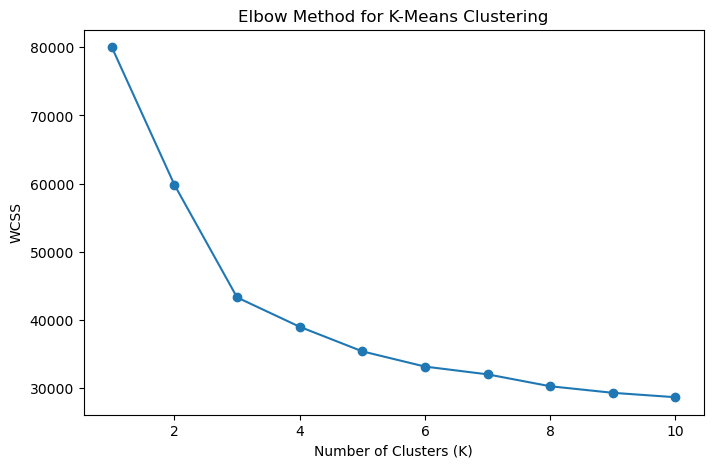

In [57]:
# Plot the Elbow Method

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for K-Means Clustering")
plt.show()

### Interpretation

The largest reduction in WCSS occurs before the curve begins to flatten. The elbow is most reasonably taken around **K = 3** for this project. Therefore, three clusters are selected for the final segmentation. The exact choice should be treated as a practical segmentation decision rather than as proof that three clusters are uniquely optimal.

## Create the K-Means Model

In [62]:
# Create K-Means model with 3 clusters

kmeans_3 = KMeans(n_clusters=3, random_state=42)

df1["Cluster_3"] = kmeans_3.fit_predict(X_scaled)

In [63]:
# Create K-Means model with 4 clusters

kmeans_4 = KMeans(n_clusters=4, random_state=42)

df1["Cluster_4"] = kmeans_4.fit_predict(X_scaled)

In [64]:
# Calculate the average characteristics of Cluster 3

df1.groupby("Cluster_3").mean()

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,days_in_inventory,stockout_frequency,backorder_frequency,return_rate,...,subcategory_Tools,subcategory_Writing Tools,warehouse_zone_A2,warehouse_zone_B1,warehouse_zone_B2,warehouse_zone_C1,warehouse_zone_C2,warehouse_zone_D1,warehouse_zone_D2,Cluster_4
Cluster_3,,,,,,,,,,,,,,,,,,,,,
0,-1.100506,0.281755,-0.102004,-0.266078,-1.061058,-1.120563,1.211292,-0.562505,-0.536889,0.359143,...,0.023112,0.018490,0.136364,0.127119,0.114792,0.137134,0.117874,0.115562,0.123267,0.012327
1,0.846006,-0.832031,-0.764426,-0.864265,0.591872,0.851716,-0.734289,-0.561401,-0.502600,-0.400330,...,0.028715,0.029433,0.127064,0.109117,0.111271,0.145011,0.128500,0.129218,0.119885,1.001436
2,0.190963,0.606036,0.914627,1.183567,0.422288,0.204774,-0.419704,1.155204,1.067229,0.069894,...,0.027502,0.029794,0.117647,0.132926,0.128342,0.126814,0.129870,0.122231,0.124523,2.533231


In [65]:
# Calculate the average characteristics of Cluster 4

df1.groupby("Cluster_4").mean()

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,days_in_inventory,stockout_frequency,backorder_frequency,return_rate,...,subcategory_Tools,subcategory_Writing Tools,warehouse_zone_A2,warehouse_zone_B1,warehouse_zone_B2,warehouse_zone_C1,warehouse_zone_C2,warehouse_zone_D1,warehouse_zone_D2,Cluster_3
Cluster_4,,,,,,,,,,,,,,,,,,,,,
0,-1.102425,0.280992,-0.109941,-0.271886,-1.062024,-1.122730,1.216389,-0.566982,-0.540062,0.361115,...,0.023256,0.018605,0.137209,0.127132,0.115504,0.135659,0.117054,0.115504,0.123256,0.000000
1,0.845924,-0.832877,-0.765258,-0.865021,0.591746,0.851398,-0.734330,-0.561918,-0.502979,-0.400179,...,0.028736,0.029454,0.127155,0.109195,0.111351,0.145115,0.127874,0.129310,0.119971,1.000000
2,-0.358961,0.342986,1.451535,1.404731,-0.167878,-0.325004,-0.023932,0.641690,0.606868,0.037167,...,0.022617,0.022617,0.116317,0.142165,0.116317,0.111470,0.140549,0.122779,0.138934,1.974152
3,0.667809,0.836304,0.441433,0.980420,0.930210,0.664311,-0.761288,1.597125,1.460909,0.097575,...,0.031474,0.035765,0.117310,0.124464,0.137339,0.143062,0.123033,0.121602,0.111588,1.998569


### Interpretation

The cluster profile compares the average business characteristics of the three segments in their original units. This is more useful for business interpretation than the standardized values because demand remains in units, lead time remains in days, and inventory value remains in monetary units.

## 21. Visualize the Clusters Using PCA

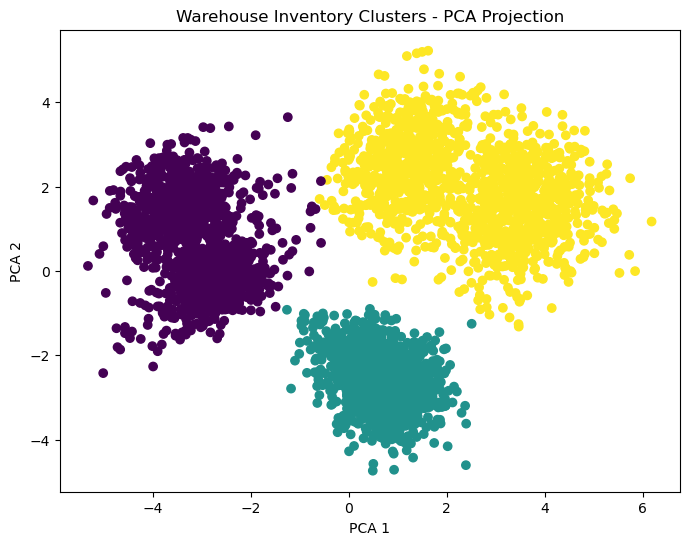

In [68]:
# 21. Visualize the clusters using PCA

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df1["Cluster_3"]
)

plt.title("Warehouse Inventory Clusters - PCA Projection")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

### Interpretation

The PCA visualization shows how the three product clusters are positioned in a reduced two-dimensional space. Products that appear close together have more similar overall characteristics, while products farther apart are more different. Because PCA retains about 48.16% of the variance in these two dimensions, the plot should be used as a visual aid rather than as a complete representation of the clustering structure.

# Cluster Insights

The K-Means model has divided the customers into three clusters: Cluster 0, Cluster 1, and Cluster 2. The cluster averages show clear differences in customer activity and transaction behavior.

## Cluster 0 — Low Activity Customers
    Average account age: 17.34 months
    Active days per month: 6.08 days
    Transactions per day: 1.24
    Average transaction amount: 478.86
    Maximum transaction amount: 1,267.79
    Merchant transaction ratio: 0.48

## Interpretation:
Cluster 0 represents customers with relatively low activity. They are active for the fewest days per month and make the fewest transactions per day. Their average and maximum transaction amounts are also the lowest among the three clusters. This indicates a comparatively low-engagement and low-transaction-value customer segment.

## Cluster 1 — Highly Active Customers
    Average account age: 17.63 months
    Active days per month: 20.35 days
    Transactions per day: 4.86
    Average transaction amount: 986.53
    Maximum transaction amount: 2,598.90
    Merchant transaction ratio: 0.68

## Interpretation:
Cluster 1 represents highly active customers. They have the highest number of active days per month and the highest merchant transaction ratio. Their transaction frequency and average transaction amount are also considerably higher than Cluster 0. This suggests a segment of regular and engaged customers with relatively strong transaction activity.

## Cluster 2 — High-Value / High-Transaction Customers
    Average account age: 17.43 months
    Active days per month: 14.14 days
    Transactions per day: 8.56
    Average transaction amount: 1,581.71
    Maximum transaction amount: 5,244.60
    Merchant transaction ratio: 0.41

## Interpretation:
Cluster 2 has the highest transaction frequency and transaction values. Although these customers are active on fewer days than Cluster 1, they make the highest number of transactions per day. They also have the highest average and maximum transaction amounts. This indicates a high-value transaction segment, where customers may transact heavily when they are active.

## Overall Insight

### The clustering identifies three distinct customer behavior segments:
| Cluster       | Main Characteristic                                         |
| ------------- | ----------------------------------------------------------- |
| **Cluster 0** | Low activity and low transaction value                      |
| **Cluster 1** | Highly active and regularly engaged customers               |
| **Cluster 2** | Highest transaction frequency and highest transaction value |


## Final Project Insight

The three clusters demonstrate that customer activity and transaction value do not necessarily increase in exactly the same way. Cluster 1 customers are active on the most days, whereas Cluster 2 customers make the most transactions and have the highest transaction amounts.

## Therefore, the business could use different strategies for each segment:
    Cluster 0: Focus on engagement and encouraging more frequent transactions.
    Cluster 1: Focus on retention and loyalty because these customers are consistently active.
    Cluster 2: Focus on high-value customer retention, personalized offers, and maintaining strong customer relationships because they generate the highest transaction activity and values.